In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load by file name
R2502_2504 = pd.read_pickle("R2502_2504.pkl")
R2504_2502 = pd.read_pickle("R2504_2502.pkl")
F2504 = pd.read_pickle("2504.pkl")

In [3]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-E")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-E2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-E*DIFF-PRESS-15min.txt"):
    print("found:", p.name)


/home/seismic/AxialFetch/MJ03F-E → True (dir)
/home/seismic/AxialFetch/MJ03F-E/MJ03F-E2022DIFF-PRESS-15min.txt → True
found: MJ03F-E2023DIFF-PRESS-15min.txt
found: MJ03F-E2022DIFF-PRESS-15min.txt
found: MJ03F-E2021DIFF-PRESS-15min.txt
found: MJ03F-E2020DIFF-PRESS-15min.txt
found: MJ03F-E2019DIFF-PRESS-15min.txt
found: MJ03F-E2018DIFF-PRESS-15min.txt
found: MJ03F-E2017DIFF-PRESS-15min.txt
found: MJ03F-E2016DIFF-PRESS-15min.txt
found: MJ03F-E2015DIFF-PRESS-15min.txt
found: MJ03F-E2014DIFF-PRESS-15min.txt
found: MJ03F-E2024DIFF-PRESS-15min.txt


In [7]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['central_p']= (cp['depth']/0.67)*6.89476

Rows in df_pressure: 1020


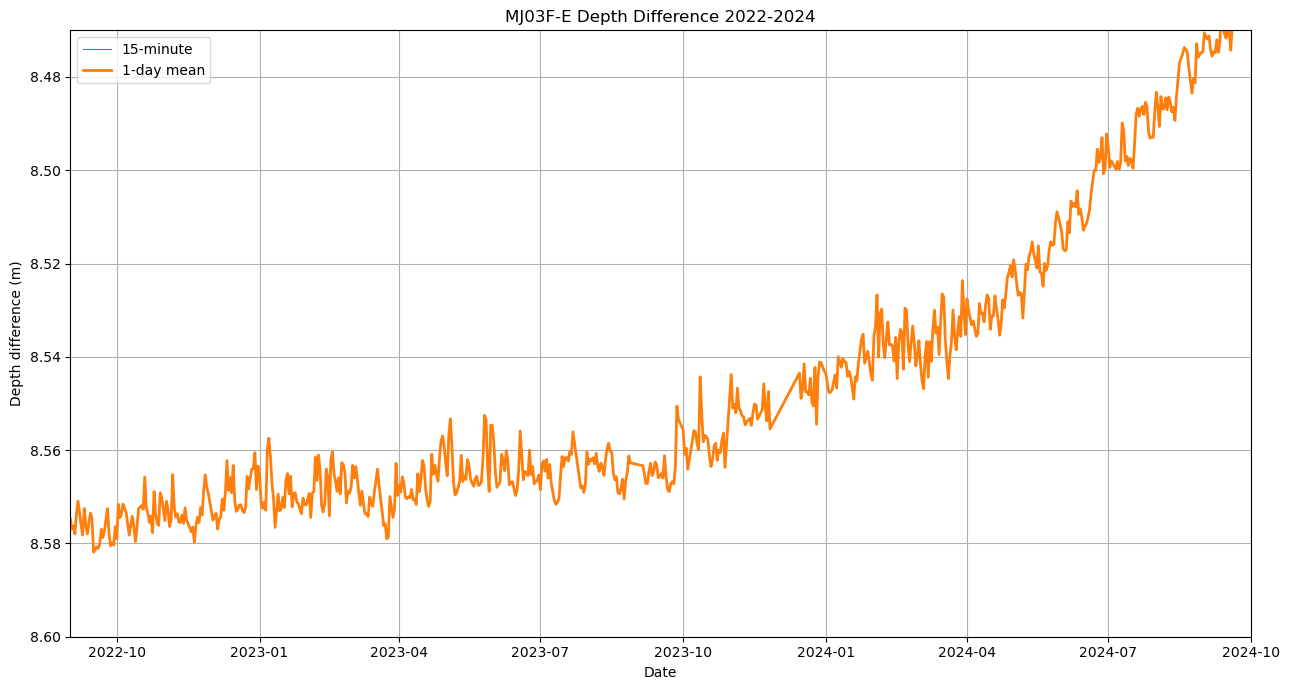

In [8]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.47)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2502_2504, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------

# distance opposite direction d2
d2 = to_series(R2504_2502, "Record Time", "Moving Average")


# -- 1. create dp (pressure-difference) --------------------------------------
dp = (
    df_pressure
        .assign(time=pd.to_datetime(df_pressure["time"], utc=True))
        .set_index("time")["pressure_diff"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 2. create cp1 (central pressure) ----------------------------------------
cp1 = (
    cp
        .assign(time=pd.to_datetime(cp["time"], utc=True))
        .set_index("time")["central_p"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 3. combine, align on common timestamps, compute p1 = cp1 – dp ----------
pressure_df = (
    pd.concat({"cp1": cp1, "dp": dp}, axis=1)   # align on DateTime index
      .dropna(subset=["cp1", "dp"])             # keep rows where BOTH exist
)

pressure_df["p1"] = pressure_df["cp1"] - pressure_df["dp"]

# -- 4. tidy up columns -------------------------------------------------------
pressure_df.index.name = "Datetime"             # give index a name
pressure_df = pressure_df.reset_index()[["Datetime", "p1", "cp1"]]


In [16]:
p1 = to_series(pressure_df, "Datetime", "p1")
p2 = to_series(pressure_df, "Datetime", "cp1")

In [17]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "d1", "d2"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [18]:
df_var = df_var.dropna().reset_index(drop=True)

import pandas as pd

cutoff = pd.Timestamp(2022, 9, 7, tz="UTC")

# ensure 'time' is datetime and remove earlier rows
df_var["Record Time"] = pd.to_datetime(df_var["Record Time"], utc=True)
df_var = df_var[df_var["Record Time"] >= cutoff].reset_index(drop=True)


In [19]:
df_var['d1'] = df_var['d1']/100
df_var['d2'] = df_var['d2']/100
df_var

,Record Time,p1,p2,d1,d2
0,2022-09-07 03:30:00+00:00,15527.605069,15540.401939,1642.111841,1642.100554
1,2022-09-07 07:30:00+00:00,15527.545432,15540.342939,1642.109057,1642.097716
2,2022-09-07 19:30:00+00:00,15527.366520,15540.165939,1642.107138,1642.097281
3,2022-09-07 23:30:00+00:00,15527.306883,15540.106939,1642.105635,1642.095712
4,2022-09-08 03:30:00+00:00,15527.270752,15540.071350,1642.103049,1642.093298
...,...,...,...,...,...
3814,2024-09-04 03:30:00+00:00,15525.354305,15537.998506,1642.185344,1642.186758
3815,2024-09-04 07:30:00+00:00,15525.337429,15537.982384,1642.185284,1642.186748
3816,2024-09-04 11:30:00+00:00,15525.320553,15537.966262,1642.184816,1642.186299
3817,2024-09-04 15:30:00+00:00,15525.303676,15537.950140,1642.184677,1642.186124


Text(0.5, 1.0, 'Central - East Distance')

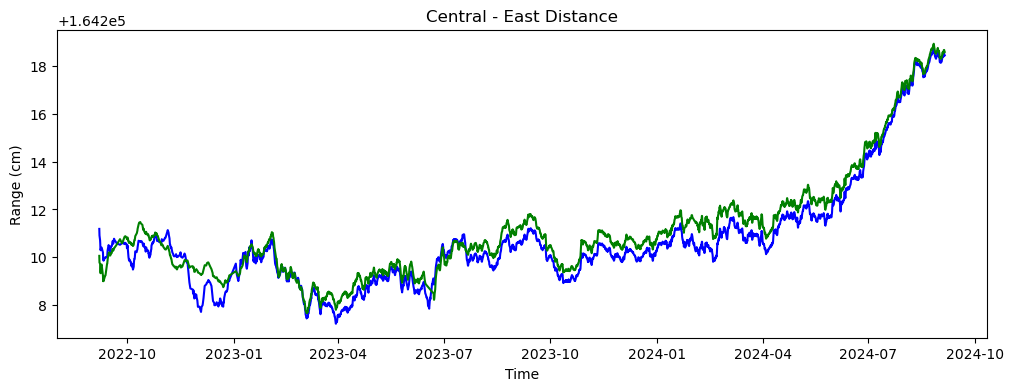

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'],df_var['d1']*100,"blue")
plt.plot(df_var['Record Time'],df_var['d2']*100,"green")
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Central - East Distance")

In [28]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time = df_var['Record Time'].values
p1   = df_var['p1'].values          # differential pressure (ΔP)
p2   = df_var['p2'].values          # absolute pressure  (P)
r_CE = df_var['d1'].values          # range E → C
r_EC = df_var['d2'].values          # range C → E

#-------------------------------------------------
# 2) TIME → FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

#-------------------------------------------------
# 4) STANDARDISE PRESSURES  (z-score keeps sign but removes offset)
#-------------------------------------------------
p1_std = (p1 - p1.mean()) / p1.std()
p2_std = (p2 - p2.mean()) / p2.std()

#-------------------------------------------------
# 5) DESIGN MATRIX  (N × 5)  with intercept
#     R(t) = C + a·p1_std + b·p2_std + c·sin + d·cos
#-------------------------------------------------
A = np.column_stack([np.ones_like(p1), p1_std, p2_std, sin_t, cos_t])

#-------------------------------------------------
# 6) LEAST-SQUARES FITS
#-------------------------------------------------
x_CE, *_ = np.linalg.lstsq(A, r_CE, rcond=None)   # (C_CE, a_CE, b_CE, c_CE, d_CE)
x_EC, *_ = np.linalg.lstsq(A, r_EC, rcond=None)   # (C_EC, a_EC, b_EC, c_EC, d_EC)

r_CE_fit = A @ x_CE
r_EC_fit = A @ x_EC

#-------------------------------------------------
# 7) RESULTS
#-------------------------------------------------
print("==== Range C→E coefficients ====")
print(f"C_CE (intercept) : {x_CE[0]:.6f}")
print(f"a_CE (Pe std)    : {x_CE[1]:.6f}")
print(f"b_CE (Pc  std)    : {x_CE[2]:.6f}")
print(f"c_CE (annual sin): {x_CE[3]:.6f}")
print(f"d_CE (annual cos): {x_CE[4]:.6f}")

print("\n==== Range E→C coefficients ====")
print(f"C_EC (intercept) : {x_EC[0]:.6f}")
print(f"a_EC (Pe std)    : {x_EC[1]:.6f}")
print(f"b_EC (Pc  std)    : {x_EC[2]:.6f}")
print(f"c_EC (annual sin): {x_EC[3]:.6f}")
print(f"d_EC (annual cos): {x_EC[4]:.6f}")


==== Range C→E coefficients ====
C_CE (intercept) : 1642.108812
a_CE (Pe std)    : 0.183061
b_CE (Pc  std)    : -0.199767
c_CE (annual sin): 0.001764
d_CE (annual cos): 0.010615

==== Range E→C coefficients ====
C_EC (intercept) : 1642.113140
a_EC (Pe std)    : 0.192064
b_EC (Pc  std)    : -0.209250
c_EC (annual sin): 0.002680
d_EC (annual cos): 0.009243


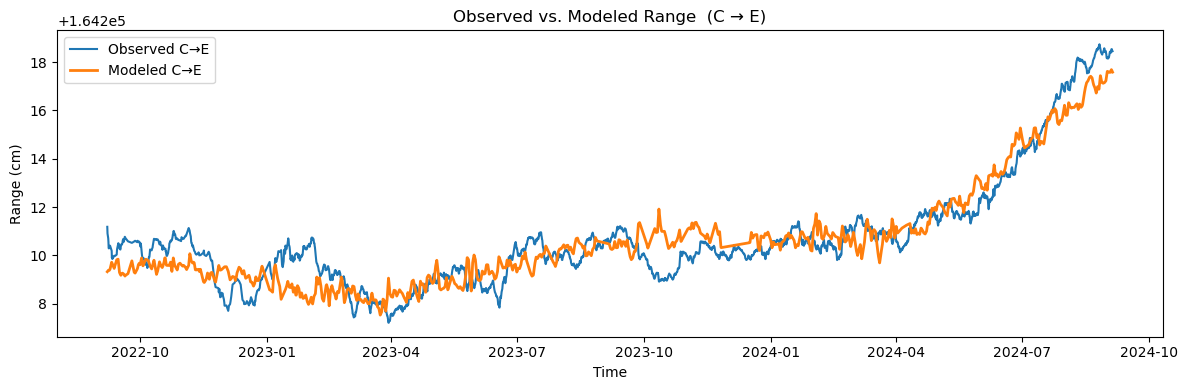

In [40]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 6)  OBSERVED vs. MODELED  –  RANGE W→C  (r_CE)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CE*100,      label='Observed C→E')
plt.plot(df_var['Record Time'], r_CE_fit*100,  label='Modeled C→E', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Observed vs. Modeled Range  (C → E)")
plt.legend()
plt.tight_layout()
plt.show()

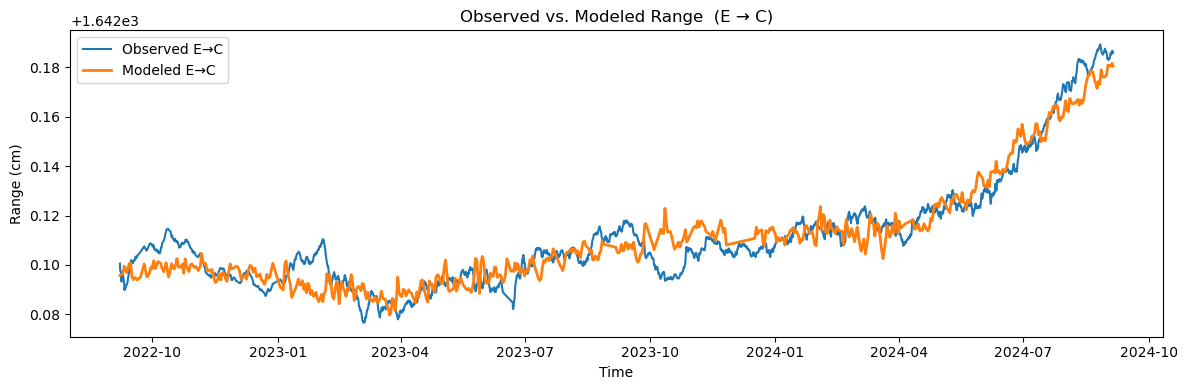

In [41]:
# ------------------------------------------------------------------
# 7)  OBSERVED vs. MODELED  –  RANGE C→W  (r_EC)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_EC,      label='Observed E→C')
plt.plot(df_var['Record Time'], r_EC_fit,  label='Modeled E→C', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Observed vs. Modeled Range  (E → C)")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import r2_score
print('R² (E→C) =', r2_score(r_EC,  r_EC_fit))
print('R² (C→E) =', r2_score(r_CE,  r_CE_fit))


R² (E→C) = 0.8956168764730716
R² (C→E) = 0.8720421913915963


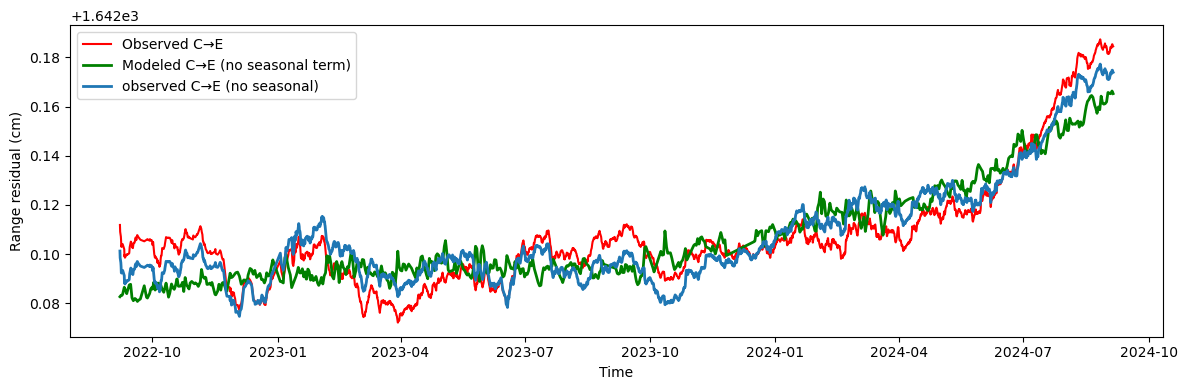

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# --- 8) SEASONAL CONTRIBUTION ---------------------------------------------
season_CE= x_CE[3] * sin_t + x_CE[4] * cos_t          #  d·sin + e·cos

# --- 9) DE-SEASONALISE -----------------------------------------------------
r_CE_deseas_fit  = r_CE_fit  - season_CE               # model     – seasonality
obs_deseas = r_CE  - season_CE                 # (leaves C + pressure terms)

# --- 10) PLOT --------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CE,"red", label='Observed C→E ')
plt.plot(df_var['Record Time'], r_CE_deseas_fit,"green", label='Modeled C→E (no seasonal term)', linewidth=2)
plt.plot(df_var['Record Time'], obs_deseas, label='observed C→E (no seasonal)', linewidth=2)
#plt.axhline(0, color='k', lw=0.75, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Range residual (cm)")
#plt.title("C → E range with annual sine/cosine removed")
plt.legend()
plt.tight_layout()
plt.show()
